In [1]:
import h5py
import numpy as np
import pandas as pd
# 读取 HDF5 文件
# with h5py.File(r'D:\HaofanWu\2023_ai_for_brain_science\way_eeg_gal\process\P1/combined_data.h5', 'r') as f:
#     eeg_sig = f['/combined_data'][:]
with h5py.File('/home/dell/remote/dreamdiffusion/dreamdiffusion/datasets/20240228/data_for_decoding.h5', 'r') as f:
    eeg_sig = f['/all_Samples'][:]
# with h5py.File(r'D:\HaofanWu\2023_ai_for_brain_science\way_eeg_gal\P1/env_sig_1_surface.h5', 'r') as f:
#     env_sig_surface = f['/data'][:]
# with h5py.File(r'D:\HaofanWu\2023_ai_for_brain_science\way_eeg_gal\P1/env_sig_1_weight.h5', 'r') as f:
#     env_sig_weight = f['/data'][:]    
with h5py.File('/home/dell/remote/dreamdiffusion/dreamdiffusion/datasets/20240228/data_for_decoding.h5', 'r') as f:
    TaskData = f['/labels'][:]   
# 现在 data 是一个 numpy 数组，包含了 Samples 的数据

In [2]:
unique_values, counts = np.unique(TaskData, return_counts=True)

print("Unique values in TaskData:", unique_values)
print("Counts of each unique value:", counts)

Unique values in TaskData: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18.]
Counts of each unique value: [115229142   3200006   3199928   3200101   3200197   3199917   3200052
   3199925   3199890   3200017   3199900   3200003   3199994   3200087
   3200018   3199945   3200122   3200003   3199937]


In [3]:
TaskData.shape

(172829184, 1)

In [4]:
eeg_sig.shape

(172829184, 16)

In [5]:
from tsai.all import *
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn import *
import glob
import os
import pathlib
import re
import pickle
from sklearn.metrics import classification_report

In [6]:
eeg_sig.shape

(172829184, 16)

In [7]:
TaskData.shape

(172829184, 1)

In [8]:
# data = np.concatenate((eeg_sig, env_sig_surface), axis=1)
data = np.concatenate((eeg_sig, TaskData), axis=1)
data.shape
# 第16列是标签，前15列是15个通道的数据，按照512先做了降采样

(172829184, 17)

In [9]:
df = pd.DataFrame(data)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-835.0,-1080.0,-278.0,-1717.0,-531.0,661.0,166.0,20.0,-1871.0,-120.0,-1383.0,-1597.0,-1015.0,-1785.0,-387.0,-480.0,1.0
1,-681.0,-1184.0,-408.0,-1466.0,-358.0,752.0,631.0,1.0,-1738.0,-177.0,-1490.0,-1544.0,-872.0,-1604.0,-214.0,-333.0,1.0
2,-806.0,-1135.0,-585.0,-1402.0,-372.0,738.0,824.0,-78.0,-1728.0,-284.0,-1533.0,-1479.0,-655.0,-1503.0,-20.0,-361.0,1.0
3,-1102.0,-955.0,-564.0,-1499.0,-304.0,633.0,731.0,-105.0,-1945.0,-318.0,-1526.0,-1542.0,-565.0,-1555.0,25.0,-480.0,1.0
4,-1235.0,-822.0,-340.0,-1641.0,-116.0,522.0,606.0,-102.0,-2104.0,-306.0,-1608.0,-1645.0,-695.0,-1737.0,-54.0,-572.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172829179,361.0,512.0,829.0,936.0,850.0,1496.0,386.0,-162.0,-1165.0,-3050.0,-446.0,469.0,548.0,-365.0,593.0,673.0,0.0
172829180,382.0,642.0,500.0,1012.0,1042.0,1536.0,181.0,23.0,-1263.0,-3170.0,-308.0,452.0,685.0,-166.0,751.0,657.0,0.0
172829181,393.0,516.0,129.0,1009.0,1273.0,1506.0,200.0,170.0,-1300.0,-3013.0,-240.0,407.0,899.0,-61.0,571.0,607.0,0.0
172829182,421.0,325.0,58.0,964.0,1387.0,1489.0,241.0,249.0,-1259.0,-2849.0,-400.0,384.0,977.0,-192.0,367.0,582.0,0.0


# 用读心术实验

In [10]:
# 自己的读心术实验
def merge_ndarrays(arrays):
    return np.concatenate(arrays, axis=0)

def My_Sliding_window(data, window_size, sample,event_threshold,vars):
#     number = int(( window_size - 1) / 2)
    # 前后时间序列补0 静态数据补均值（就一个值）
    df = data.drop(data.columns[-1], axis=1)
    num_rows = df.shape[0]
    # 先都填0了，等心情好的时候再优化
    if num_rows % sample == 0:
        flag_result = 1
    else: # 不能整除
        flag_result = 0    
    number = (window_size - 1) // 2
    zeros_data = np.zeros((number, df.shape[1]))
    zeros_df = pd.DataFrame(zeros_data, columns=df.columns)
    df = pd.concat([zeros_df, df, zeros_df])  
    
    
#     zero_fill_columns = ['Time', 'AccV', 'AccML', 'AccAP','Time_frac']
#     mean_fill_columns = list(set(df.columns) - set(zero_fill_columns))
#     for column in mean_fill_columns:
#         mean_value = df[column].mean()
#         fill_value = np.full(number, mean_value)
#         df[column] = np.concatenate((fill_value, df[column].values, fill_value))


#     new_data = pd.DataFrame()
    if flag_result == 1:
        new_data = np.zeros((num_rows//sample, vars, window_size))
    elif flag_result == 0:
        new_data = np.zeros(((num_rows // sample)+1, vars, window_size))  
        
    new_data_y = pd.DataFrame()
    for i in range(int((window_size - 1) / 2), num_rows + int((window_size - 1) / 2),sample):
        X = df.iloc[i - int((window_size - 1) / 2):i + int((window_size - 1) / 2) + 1, :]
#         print(X)
        if X.shape != (window_size, vars):
            print('error 1')
        new_data[(i-number)//sample, :, :] = X.T            
            
        # 处理X
#         X = df.iloc[i - int((window_size - 1) / 2):i + int((window_size - 1) / 2) + 1, :]
#         x_flatten = X.values.T.flatten()
        # 49是变量数，应该用参数传进来的
#         if len(x_flatten) != 49 * window_size:
#             print('error 1')
#         new_data = new_data.append(pd.DataFrame(x_flatten).T, ignore_index=True)
        
        # 处理Y
        event_threshold_count = sample * event_threshold
        target_counts = data.iloc[i:i + sample].iloc[:,-1].value_counts()
#         print(target_counts)
#         target_counts = data.iloc[i:i + sample]["target"].value_counts()


# 这段是以前固定标签数量的
#         # 判断数量是否符合要求，决定 y 的值
#         if target_counts.get(1,0) > event_threshold_count:
#             y = 1
#         elif target_counts.get(2,0) > event_threshold_count:
#             y = 2
#         elif target_counts.get(3,0) > event_threshold_count:
#             y = 3
#         elif target_counts.get(4,0) > event_threshold_count:
#             y = 4 
#         elif target_counts.get(5,0) > event_threshold_count:
#             y = 5  
#         else:        
#             y = 0
            
#       这行是现在可以有任意标签数量的
        y = next((idx for idx, val in target_counts.items() if val > event_threshold_count), 0)
  
            
            
        new_data_y = new_data_y.append(pd.DataFrame([y]), ignore_index=True)
#         new_data_y = new_data_y.values.reshape(-1)
#     print(new_data.shape)
#     new_shape = (new_data.shape[0], 49, -1)
#     new_data = new_data.values
#     new_arr_train = new_data.reshape(new_shape)
#     X = new_arr_train.transpose(0, 1, 2)
#     X = X.values
    return new_data ,new_data_y.values.reshape(-1)

In [11]:
X_list = []
y_list = []
# columns = df_all.columns.tolist()
# get_x = [col for col in columns if col != 'target']
# get_y = 'target'
# var = df_all.shape[1]-1
#这里目前必须是奇数
#  32000是一秒
window_length = 8001
stride = 8000
event_threshold = 0.9
var = 16
#     Slidingdata = data.drop(['target'], axis=1)
X,y = My_Sliding_window(data = df,window_size=window_length, sample=stride,event_threshold = event_threshold,vars = var)
#     X, y = SlidingWindow(window_len=window_length, stride = stride, padding='pre',  start =0,get_x=get_x, get_y=get_y)(data)

#     print(X.shape)
#     print(y.shape)
#     if X.shape[0] != y.shape[0]:
#         print('error 4')
X_list.append(X)
y_list.append(y)
X_all = merge_ndarrays(X_list)
y_all = merge_ndarrays(y_list)

In [12]:
X_all.shape

(21604, 16, 8001)

In [13]:
y_all.shape

(21604,)

In [14]:
# 找到所有标签为0的索引
zero_indices = np.where(y_all == 0)[0]

# 删除选定的索引
X_all = np.delete(X_all, zero_indices, axis=0)
y_all = np.delete(y_all, zero_indices, axis=0)



print('X_all.shape')
print(X_all.shape)
print('y_all.shape')
print(y_all.shape)

X_all.shape
(6300, 16, 8001)
y_all.shape
(6300,)


In [15]:
y_all

array([ 1.,  1.,  1., ..., 18., 18., 18.])

In [16]:
# y_series = pd.Series(y_all)
y_series = pd.Series(y_all)

# 统计每个值的数量，并计算比例
target_counts = y_series.value_counts()
target_total = target_counts.sum()



target_ratios = target_counts / target_total

# for label,ratio in target_ratios.item():
#     print(f"{label} : {ratio:.1f}")
print(target_ratios)


# # 计算每个标签的比例
# # target0_ratio = np.float32(target_counts[0] / target_total)
# target1_ratio = np.float32(target_counts[1] / target_total)
# target2_ratio = np.float32(target_counts[2] / target_total)
# target3_ratio = np.float32(target_counts[3] / target_total)
# target4_ratio = np.float32(target_counts[4] / target_total)
# target5_ratio = np.float32(target_counts[5] / target_total)
# # target6_ratio = np.float32(target_counts[6] / target_total)

# # 打印每个标签的比例
# # print(target0_ratio)
# print(target1_ratio)
# print(target2_ratio)
# print(target3_ratio)
# print(target4_ratio)
# print(target5_ratio)
# print(target6_ratio)


1.0     0.055556
2.0     0.055556
3.0     0.055556
4.0     0.055556
5.0     0.055556
6.0     0.055556
7.0     0.055556
8.0     0.055556
9.0     0.055556
10.0    0.055556
11.0    0.055556
12.0    0.055556
13.0    0.055556
14.0    0.055556
15.0    0.055556
16.0    0.055556
17.0    0.055556
18.0    0.055556
dtype: float64


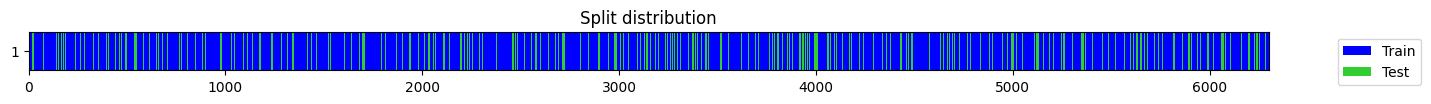

(#6300) [(TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0))] ...]

In [17]:
splits = get_splits(y_all, valid_size=.2, stratify=True, random_state=27, shuffle=True)
# splits = get_splits(y_all, valid_size =.2, stratify=True, random_state=23, shuffle=False)


tfms  = [None, [Categorize()]]
dsets = TSDatasets(X_all, y_all, tfms=tfms, splits=splits, inplace=True)
dsets

In [18]:
dls = TSDataLoaders.from_dsets(dsets.train, dsets.valid, bs=160, batch_tfms=[TSStandardize(by_var=True)])

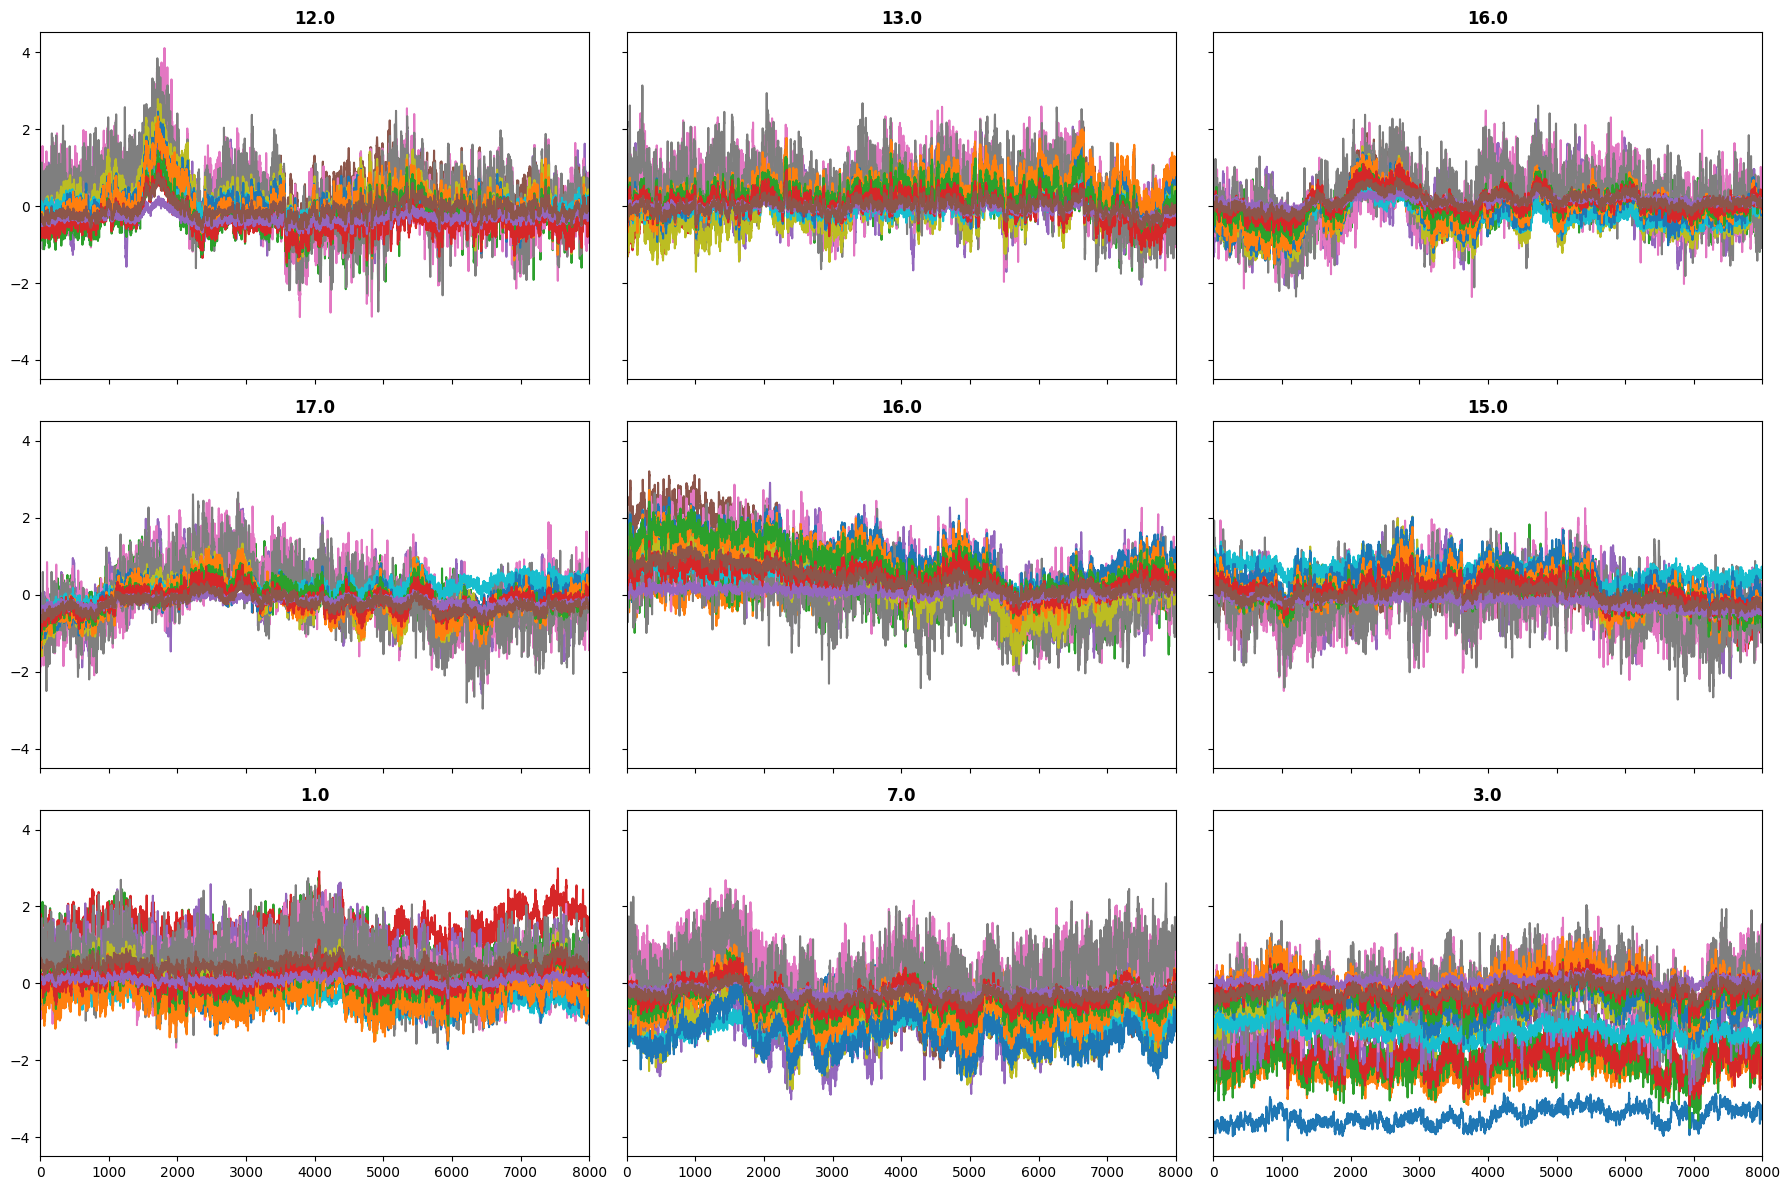

In [19]:
dls.show_batch(sharey=True)

In [20]:
# loss_func = CrossEntropyLossFlat(weight=class_weights)  # 使用设置的损失权重
model = InceptionTime(dls.vars, dls.c)
learn = Learner(dls, model, metrics=accuracy,  cbs=ShowGraphCallback2())
# learn.lr_find()
# learn.loss_func = loss_func  # 使用设置的损失函数
# learn.save('stage0')

SuggestedLRs(valley=0.0014454397605732083)

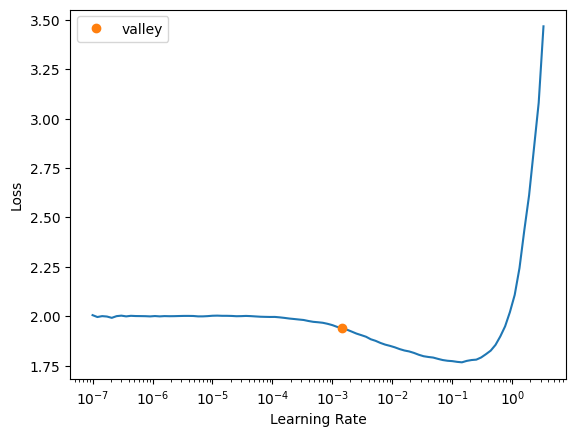

In [15]:

model = LSTM_FCNPlus(dls.vars, dls.c,dls.len)
learn = Learner(dls, model, metrics=accuracy,  cbs=ShowGraphCallback2())
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,time
0,2.906608,2.904105,0.057937,00:17
1,2.838047,2.803376,0.126190,00:14
2,2.786939,2.765282,0.145238,00:14
3,2.738096,2.724923,0.159524,00:14
4,2.692731,2.684058,0.180159,00:14
5,2.647907,2.639784,0.197619,00:13
6,2.604127,2.594279,0.203175,00:14
7,2.559721,2.563164,0.212698,00:13
8,2.516289,2.525417,0.234127,00:13
9,2.477076,2.484112,0.243651,00:13


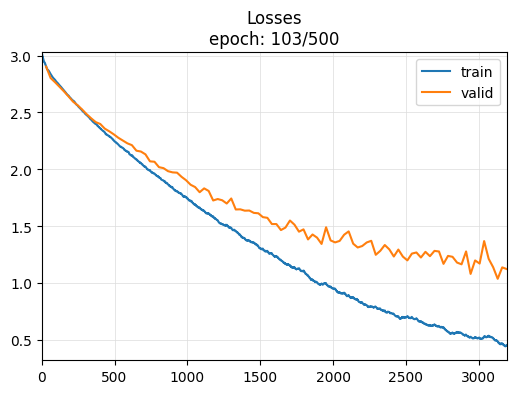

In [ ]:
learn.fit_one_cycle(500, 8*1e-4)
# learn.export("2023_transformer_test.pkl")
# learn.export(fname='onlyexport/model_InceptionTime_20230421_2.pkl')
# learn.save('stage1')


In [25]:
learn.export(fname='onlyexport/model_InceptionTime.pkl')

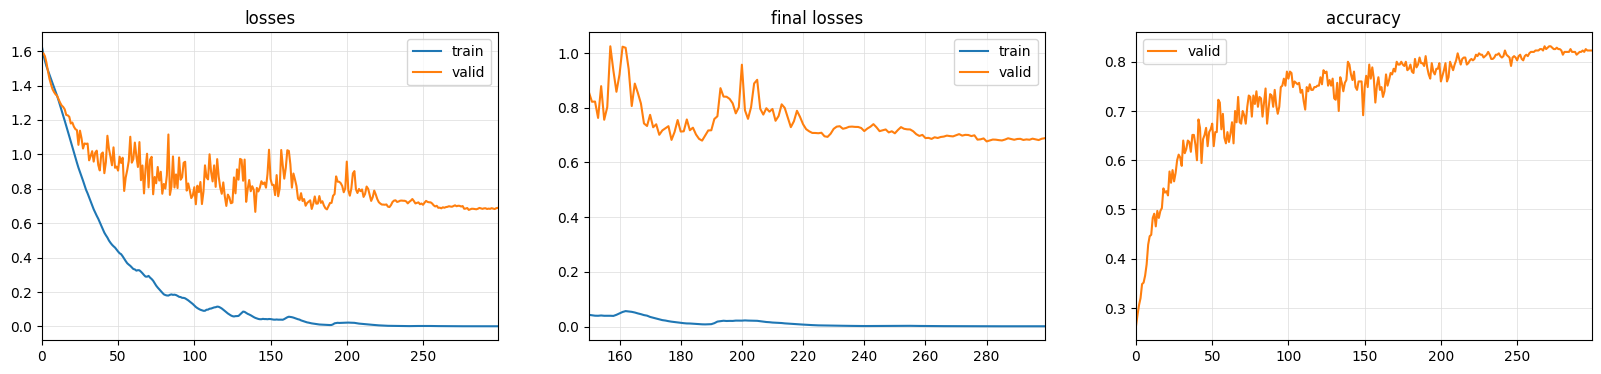

In [25]:
learn.recorder.plot_metrics()

In [26]:
valid_dl = dls.valid
valid_probas, valid_targets, valid_preds = learn.get_preds(dl=valid_dl, with_decoded=True)
valid_probas, valid_targets, valid_preds


(TensorBase([[1.6617e-03, 1.8076e-02, 1.4910e-02, 9.2551e-01, 3.9845e-02],
             [2.5622e-07, 1.0000e+00, 1.1745e-06, 4.7168e-08, 1.9013e-07],
             [8.9722e-04, 2.1725e-06, 7.7492e-06, 9.9909e-01, 7.8406e-07],
             ...,
             [8.7593e-01, 2.0002e-02, 7.4376e-02, 2.9531e-02, 1.5861e-04],
             [1.6228e-05, 2.8921e-05, 9.9988e-01, 1.7028e-05, 5.6718e-05],
             [1.9641e-01, 3.7262e-01, 7.9676e-03, 4.6359e-03, 4.1837e-01]]),
 tensor([3, 1, 3, 2, 2, 1, 0, 2, 1, 4, 0, 4, 4, 1, 1, 2, 3, 4, 3, 3, 2, 0, 3, 3,
         4, 0, 4, 1, 0, 3, 4, 3, 0, 0, 3, 4, 2, 2, 1, 4, 4, 4, 2, 3, 0, 0, 4, 4,
         0, 3, 1, 3, 2, 2, 2, 4, 0, 3, 4, 3, 4, 3, 4, 0, 1, 3, 0, 2, 1, 3, 2, 1,
         2, 4, 2, 1, 1, 4, 0, 0, 1, 4, 2, 3, 1, 0, 0, 1, 3, 4, 3, 0, 2, 2, 1, 3,
         0, 0, 1, 0, 3, 3, 1, 3, 0, 4, 2, 1, 3, 2, 2, 3, 3, 4, 4, 2, 3, 2, 4, 0,
         2, 2, 2, 1, 1, 1, 4, 3, 3, 1, 3, 4, 3, 4, 0, 3, 2, 1, 0, 1, 1, 1, 1, 4,
         3, 0, 4, 2, 4, 2, 2, 1, 4, 2, 4, 1,

2276

In [74]:
after_target_counts = valid_targets.numpy()
# after_target_counts = valid_preds.numpy()
after_target_counts = pd.DataFrame(after_target_counts)
after_target_counts = after_target_counts.value_counts()
target_total = after_target_counts.sum()
target0_ratio = np.float32(after_target_counts[0] / target_total)
target1_ratio = np.float32(after_target_counts[1] / target_total)

print(target0_ratio)
print(target1_ratio)
print(target_total)

0.6717624
0.32823756
5691


In [27]:
valid_preds

TensorBase([3, 1, 3, 0, 2, 3, 0, 2, 1, 4, 2, 4, 4, 4, 4, 2, 3, 4, 2, 3, 2, 0, 3,
            3, 4, 0, 4, 1, 0, 3, 4, 3, 0, 0, 3, 4, 2, 2, 1, 3, 4, 4, 2, 4, 4, 0,
            4, 2, 0, 3, 1, 2, 2, 2, 2, 4, 0, 3, 4, 3, 4, 3, 4, 0, 1, 3, 0, 2, 4,
            3, 2, 4, 2, 4, 2, 0, 1, 3, 0, 1, 1, 4, 2, 3, 1, 0, 0, 1, 3, 4, 4, 0,
            3, 2, 1, 3, 0, 0, 3, 0, 3, 3, 1, 3, 2, 4, 1, 1, 3, 2, 2, 0, 3, 4, 1,
            3, 3, 0, 4, 2, 2, 2, 2, 1, 1, 1, 4, 3, 3, 1, 3, 3, 3, 4, 1, 3, 2, 3,
            3, 1, 0, 1, 0, 4, 3, 0, 4, 3, 4, 2, 2, 1, 4, 2, 4, 1, 4, 2, 0, 4, 4,
            0, 4, 1, 1, 3, 0, 1, 0, 1, 4, 0, 3, 4, 0, 3, 0, 3, 0, 3, 2, 1, 0, 2,
            0, 2, 1, 0, 2, 0, 4, 3, 1, 2, 4, 0, 2, 3, 2, 3, 1, 0, 4, 2, 3, 0, 4,
            0, 4, 0, 1, 2, 2, 3, 0, 4, 1, 4, 0, 1, 2, 3, 2, 2, 1, 1, 0, 4, 4, 3,
            2, 1, 2, 4, 2, 0, 2, 2, 0, 3, 2, 3, 3, 0, 1, 4, 1, 3, 3, 2, 2, 2, 2,
            1, 4, 0, 1, 1, 0, 0, 2, 4, 3, 4, 0, 0, 3, 0, 1, 2, 1, 2, 1, 4, 1, 3,
            1, 0, 4, 0, 1, 0

In [28]:
acc = accuracy_multi(valid_preds, valid_targets)
acc

TensorBase(0.9229)

In [29]:
# (valid_targets == valid_preds).float().mean()
print((valid_targets == valid_preds).float().mean())

TensorBase(0.8229)


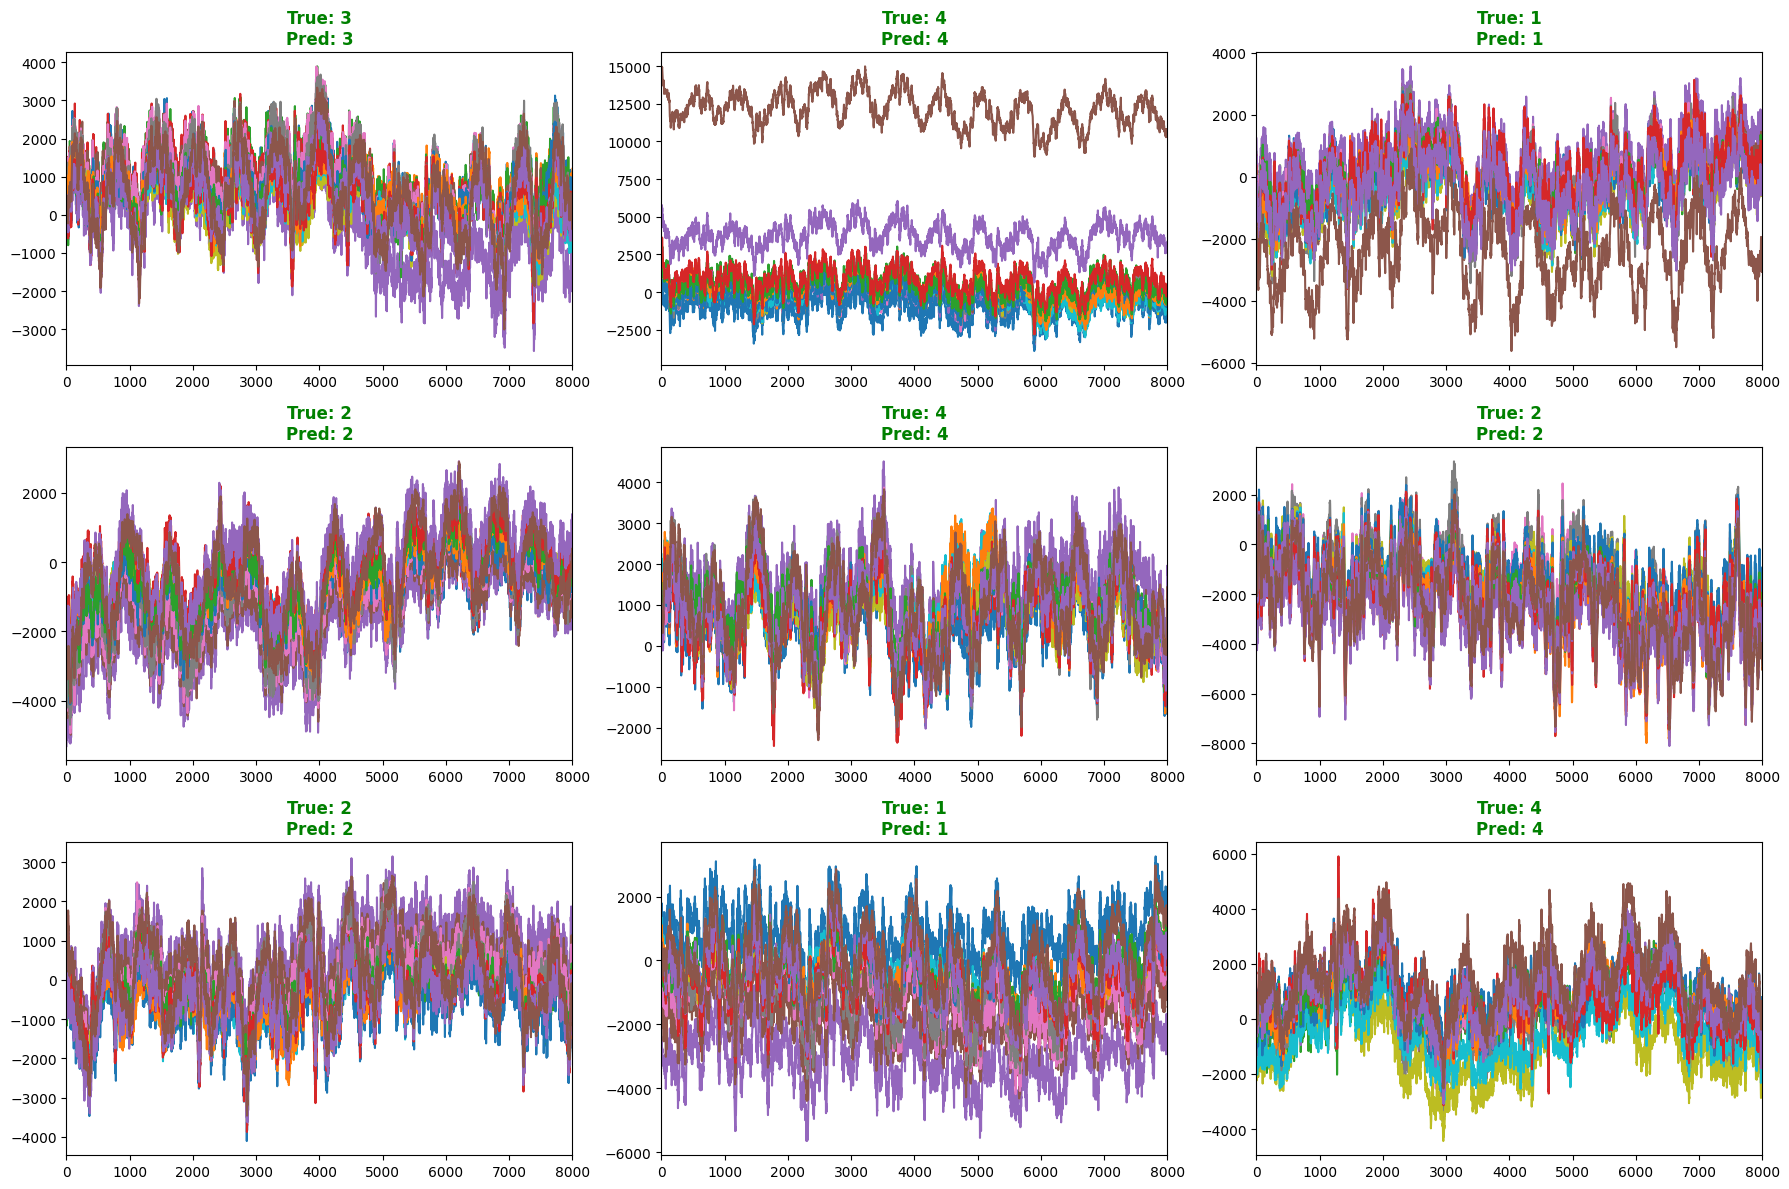

In [30]:
learn.show_results()

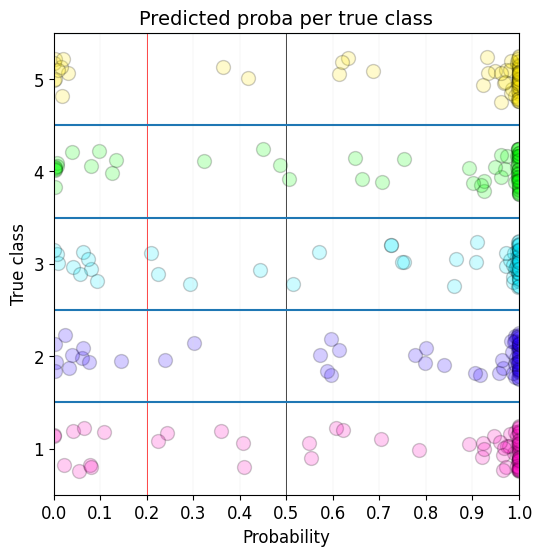

In [31]:
learn.show_probas()

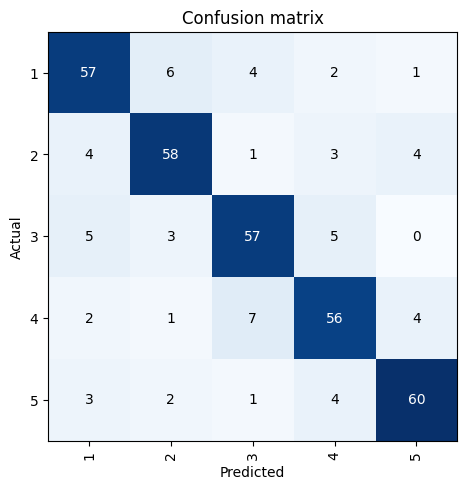

In [32]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()